#Compare Results


## 0) Paths & Constants

In [1]:
# ── All paths and settings are defined here ──────────────────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/Final Project RMOT/'
RESULTS_DIR  = '/content/drive/MyDrive/Final Project RMOT/artifacts/results'
FIGURES_DIR  = '/content/drive/MyDrive/Final Project RMOT/artifacts/figures'

In [2]:
from google.colab import drive
drive.flush_and_unmount()

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Results dir:", RESULTS_DIR)
print("Figures dir:", FIGURES_DIR)

Results dir: /content/drive/MyDrive/Final Project RMOT/artifacts/results
Figures dir: /content/drive/MyDrive/Final Project RMOT/artifacts/figures


In [18]:
#load latest results file
csv_files = glob.glob(os.path.join(RESULTS_DIR, "*.csv"))

if not csv_files:
    raise FileNotFoundError("No results CSV files found in results folder.")

latest_file = max(csv_files, key=os.path.getmtime)
print("Loading:", latest_file)

df = pd.read_csv(latest_file)
df

Loading: /content/drive/MyDrive/Final Project RMOT/artifacts/results/model_training_results_2026-04-29.csv


,date,feature_type,model_trained,accuracy,precision,recall,f1_score,auc,latency_total_s,latency_ms_sample
0,2026-04-29,wav2vec,ocsvm,0.602564,0.709677,0.771930,0.739496,0.502089,0.002354,0.030181
1,2026-04-29,wav2vec,iso_forest,0.576923,0.693548,0.754386,0.722689,0.532164,0.010683,0.136962
2,2026-04-29,wav2vec,logreg,0.833333,0.843750,0.947368,0.892562,0.794486,0.000625,0.008015
3,2026-04-29,ast,ocsvm,0.846154,0.868852,0.929825,0.898305,0.845447,0.003968,0.050875
4,2026-04-29,ast,iso_forest,0.846154,0.881356,0.912281,0.896552,0.838764,0.016886,0.216481
5,2026-04-29,ast,logreg,0.935897,0.919355,1.000000,0.957983,0.979950,0.002000,0.025642
6,2026-04-29,logmel,teacher_student,0.192308,0.200000,0.666667,0.307692,0.440267,0.616914,7.909154
7,2026-04-29,logmel,cnn,0.858974,0.812500,0.619048,0.702703,0.904762,0.305022,3.910545


In [19]:
print(df.columns.tolist())
print(df.shape)
df

['date', 'feature_type', 'model_trained', 'accuracy', 'precision', 'recall', 'f1_score', 'auc', 'latency_total_s', 'latency_ms_sample']
(8, 10)


,date,feature_type,model_trained,accuracy,precision,recall,f1_score,auc,latency_total_s,latency_ms_sample
0,2026-04-29,wav2vec,ocsvm,0.602564,0.709677,0.771930,0.739496,0.502089,0.002354,0.030181
1,2026-04-29,wav2vec,iso_forest,0.576923,0.693548,0.754386,0.722689,0.532164,0.010683,0.136962
2,2026-04-29,wav2vec,logreg,0.833333,0.843750,0.947368,0.892562,0.794486,0.000625,0.008015
3,2026-04-29,ast,ocsvm,0.846154,0.868852,0.929825,0.898305,0.845447,0.003968,0.050875
4,2026-04-29,ast,iso_forest,0.846154,0.881356,0.912281,0.896552,0.838764,0.016886,0.216481
5,2026-04-29,ast,logreg,0.935897,0.919355,1.000000,0.957983,0.979950,0.002000,0.025642
6,2026-04-29,logmel,teacher_student,0.192308,0.200000,0.666667,0.307692,0.440267,0.616914,7.909154
7,2026-04-29,logmel,cnn,0.858974,0.812500,0.619048,0.702703,0.904762,0.305022,3.910545


In [20]:
df_sorted = df.sort_values(by=["auc", "f1_score"], ascending=False).reset_index(drop=True)
df_sorted

,date,feature_type,model_trained,accuracy,precision,recall,f1_score,auc,latency_total_s,latency_ms_sample
0,2026-04-29,ast,logreg,0.935897,0.919355,1.000000,0.957983,0.979950,0.002000,0.025642
1,2026-04-29,logmel,cnn,0.858974,0.812500,0.619048,0.702703,0.904762,0.305022,3.910545
2,2026-04-29,ast,ocsvm,0.846154,0.868852,0.929825,0.898305,0.845447,0.003968,0.050875
3,2026-04-29,ast,iso_forest,0.846154,0.881356,0.912281,0.896552,0.838764,0.016886,0.216481
4,2026-04-29,wav2vec,logreg,0.833333,0.843750,0.947368,0.892562,0.794486,0.000625,0.008015
5,2026-04-29,wav2vec,iso_forest,0.576923,0.693548,0.754386,0.722689,0.532164,0.010683,0.136962
6,2026-04-29,wav2vec,ocsvm,0.602564,0.709677,0.771930,0.739496,0.502089,0.002354,0.030181
7,2026-04-29,logmel,teacher_student,0.192308,0.200000,0.666667,0.307692,0.440267,0.616914,7.909154


In [21]:
best_row = df_sorted.iloc[0]

print("Best feature set:", best_row["feature_type"])
print("Best model:",       best_row["model_trained"])
print("Best AUC:",         round(best_row["auc"], 4))
print("Best F1:",          round(best_row["f1_score"], 4))
print("Best Accuracy:",    round(best_row["accuracy"], 4))

Best feature set: ast
Best model: logreg
Best AUC: 0.9799
Best F1: 0.958
Best Accuracy: 0.9359


In [22]:
df_sorted["label"] = df_sorted["feature_type"] + " + " + df_sorted["model_trained"]
df_sorted[["label", "auc", "f1_score", "accuracy"]]

,label,auc,f1_score,accuracy
0,ast + logreg,0.979950,0.957983,0.935897
1,logmel + cnn,0.904762,0.702703,0.858974
2,ast + ocsvm,0.845447,0.898305,0.846154
3,ast + iso_forest,0.838764,0.896552,0.846154
4,wav2vec + logreg,0.794486,0.892562,0.833333
5,wav2vec + iso_forest,0.532164,0.722689,0.576923
6,wav2vec + ocsvm,0.502089,0.739496,0.602564
7,logmel + teacher_student,0.440267,0.307692,0.192308


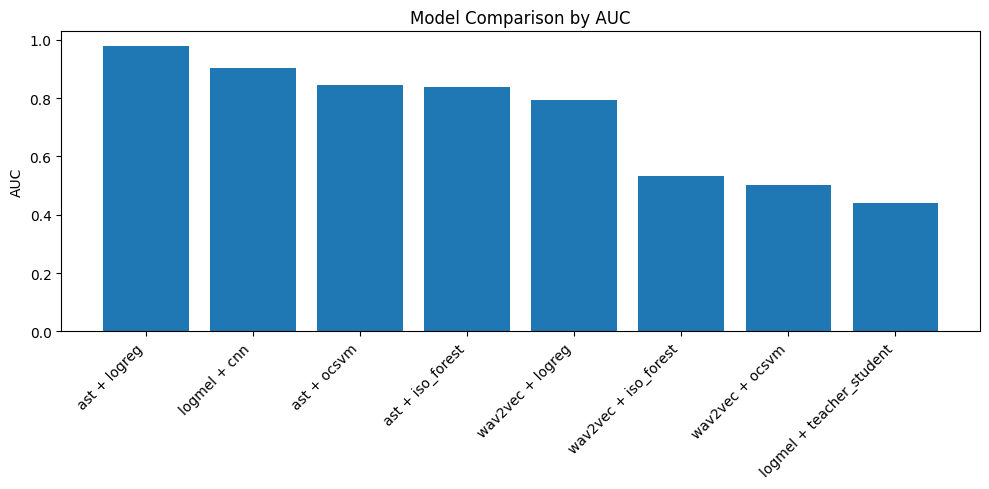

Saved plot to: /content/drive/MyDrive/Final Project RMOT/artifacts/figures/auc_comparison.png


In [23]:
plt.figure(figsize=(10, 5))
plt.bar(df_sorted["label"], df_sorted["auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC")
plt.title("Model Comparison by AUC")
plt.tight_layout()

auc_plot_path = os.path.join(FIGURES_DIR, "auc_comparison.png")
plt.savefig(auc_plot_path, bbox_inches="tight")
plt.show()

print("Saved plot to:", auc_plot_path)

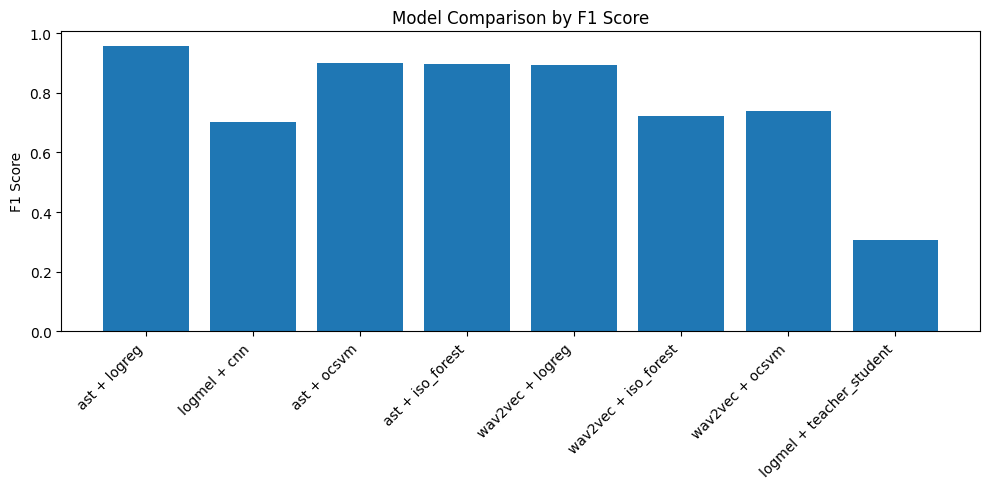

Saved plot to: /content/drive/MyDrive/Final Project RMOT/artifacts/figures/f1_comparison.png


In [24]:
plt.figure(figsize=(10, 5))
plt.bar(df_sorted["label"], df_sorted["f1_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Model Comparison by F1 Score")
plt.tight_layout()

f1_plot_path = os.path.join(FIGURES_DIR, "f1_comparison.png")
plt.savefig(f1_plot_path, bbox_inches="tight")
plt.show()

print("Saved plot to:", f1_plot_path)

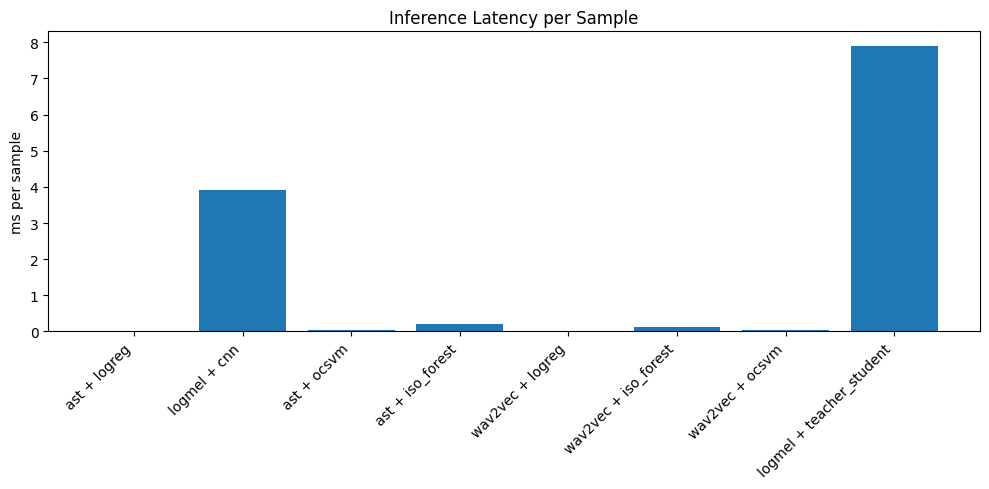

Saved plot to: /content/drive/MyDrive/Final Project RMOT/artifacts/figures/latency_comparison.png


In [25]:
# Inference latency comparison
if "latency_ms_sample" in df_sorted.columns:
    plt.figure(figsize=(10, 5))
    plt.bar(df_sorted["label"], df_sorted["latency_ms_sample"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("ms per sample")
    plt.title("Inference Latency per Sample")
    plt.tight_layout()

    latency_plot_path = os.path.join(FIGURES_DIR, "latency_comparison.png")
    plt.savefig(latency_plot_path, bbox_inches="tight")
    plt.show()

    print("Saved plot to:", latency_plot_path)

In [26]:
summary = f"""
Best overall combination:
- Feature type: {best_row['feature_type']}
- Model: {best_row['model_trained']}
- AUC: {best_row['auc']:.4f}
- F1: {best_row['f1_score']:.4f}
- Accuracy: {best_row['accuracy']:.4f}
"""

print(summary)


Best overall combination:
- Feature type: ast
- Model: logreg
- AUC: 0.9799
- F1: 0.9580
- Accuracy: 0.9359



In [27]:
feature_summary = df.groupby("feature_type")[["auc", "f1_score", "accuracy"]].mean().sort_values(by="auc", ascending=False)
feature_summary

,auc,f1_score,accuracy
feature_type,,,
ast,0.888053,0.917613,0.876068
logmel,0.672515,0.505198,0.525641
wav2vec,0.609580,0.784916,0.670940


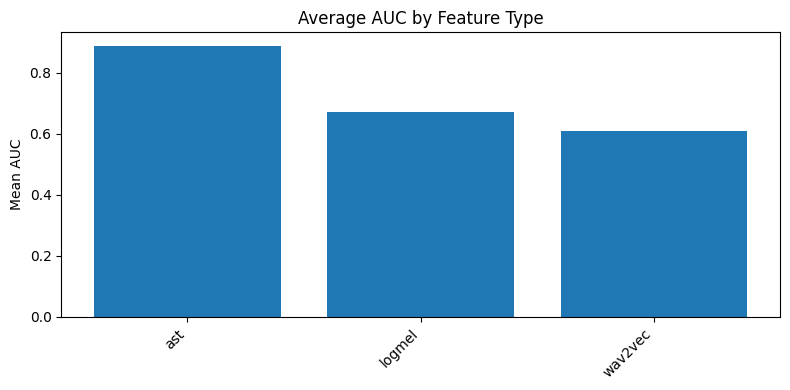

In [28]:
plt.figure(figsize=(8, 4))
plt.bar(feature_summary.index, feature_summary["auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean AUC")
plt.title("Average AUC by Feature Type")
plt.tight_layout()
plt.show()